**Table 5** (Tirado-Martin et al., 2024, *NeuroVoz*, Scientific Data) — Voice measurements extracted from the /a/ sustained vowel recordings. These are the columns in `audio_features.csv`.

| Parameter | Abbreviation | Unit Measure |
|---|---|---|
| **Perturbation Measures** | | |
| Absolute Jitter | Jitter | μSeconds |
| Relative Jitter | rJitter | % |
| Relative Average Perturbation | RAP | % |
| Pitch Period Perturbation Quotient | rPPQ | % |
| Smoothed Pitch Period Perturbation Quotient | rSPPQ | % |
| Absolute Shimmer | ShimmerDb | dB |
| Relative Shimmer | rShimmer | % |
| Amplitude Perturbation Quotient | APQ | % |
| Smoothed Amplitude Perturbation Quotient | sAPQ | % |
| Cepstral Peak Prominence | CPP | dB |
| **Noise Parameters** | | |
| Harmonics-to-Noise Ratio | HNR | dB |
| Cepstrum Harmonics-to-Noise Ratio | CHNR | dB |
| Glottal to Noise Excitation Ratio | GNE | Ratio |
| Normalised Noise Energy | NNE | dB |
| **Tremor Parameters** | | |
| Frequency Tremor Intensity Index | FTRI | Arbitrary Units |
| Amplitude Tremor Intensity Index | ATRI | Arbitrary Units |
| Fundamental Frequency Tremor Frequency | FFTR | Hz |
| Amplitude Tremor Frequency | ATRF | Hz |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

df = pd.read_csv("/Users/evelyn/Documents/claudecode/speechlab/Parkinsons/Spanish neurovoz_v3/audio_features/audio_features.csv")

def get_label(path):
    return 1 if "/PD_" in path else 0

df["label"] = df["AudioPath"].apply(get_label)

# CPP is stored as a per-frame array string (e.g. "[20.68 19.51 ...]") instead of
# a single value like the other columns, so collapse it to its mean per recording.
# Some rows were truncated by numpy's repr (long arrays get a literal "..." in the
# middle) before this CSV was saved, so those tokens are dropped rather than parsed.
def parse_cpp(s):
    tokens = [t for t in s.strip("[]\n").split() if t != "..."]
    return np.array(tokens, dtype=float).mean()

df["CPP"] = df["CPP"].apply(parse_cpp)

df.head()

,AudioPath,Jitter,rJitter,RAP,rPPQ,rSPPQ,ShimmerDb,rShimmer,APQ,sAPQ,FTRI,ATRI,FFTR,ATRF,NNE,HNR,CHNR,GNE,CPP,label
0,../data/audios/HC_A1_0034.wav,90.143459,1.389974,0.829234,0.867956,2.028272,0.306230,3.467983,2.583073,3.371838,4.090909,10.279720,0.031869,2.439872,-14.178498,-16.783000,-14.781723,-10.849439,19.632318,0
1,../data/audios/HC_A1_0036.wav,45.845768,1.053877,0.648728,0.618244,0.710986,0.274391,3.138128,2.258142,3.131371,5.646607,10.022727,0.006287,0.815829,-18.391510,-13.384067,-15.803058,-11.950162,23.623269,0
2,../data/audios/HC_A1_0045.wav,388.205756,3.534064,2.127018,1.955301,1.834815,0.902313,10.319354,6.424677,6.655715,9.111570,10.022727,0.020949,0.531205,-4.170562,-3.134168,-2.363848,-2.473592,16.511829,0
3,../data/audios/HC_A1_0048.wav,38.528686,0.473524,0.284452,0.319551,0.516492,0.396074,4.519425,3.148559,5.212512,10.279720,10.279720,0.003805,0.762209,-15.074605,-10.914691,-11.788722,-16.150904,24.883966,0
4,../data/audios/HC_A1_0049.wav,35.880701,0.702138,0.433132,0.436095,0.727694,0.320643,3.663877,2.811715,5.060773,4.310850,10.022727,0.004411,0.401193,-20.660361,-32.320082,-27.659973,-29.763608,24.182285,0


In [2]:
print(f"Shape: (rows = {df.shape[0]} audio files, cols = {df.shape[1]} features [18 MDVP measures + AudioPath + label])")
print("\nClass distribution:")
print(df["label"].value_counts())
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df = df.dropna().reset_index(drop=True)
print(f"\nAfter dropping rows with missing values: {df.shape[0]} rows remain")

Shape: (rows = 1035 audio files, cols = 20 features [18 MDVP measures + AudioPath + label])

Class distribution:
label
1    559
0    476
Name: count, dtype: int64

Missing values per column:
FTRI    4
ATRI    4
FFTR    4
ATRF    4
dtype: int64

After dropping rows with missing values: 1031 rows remain


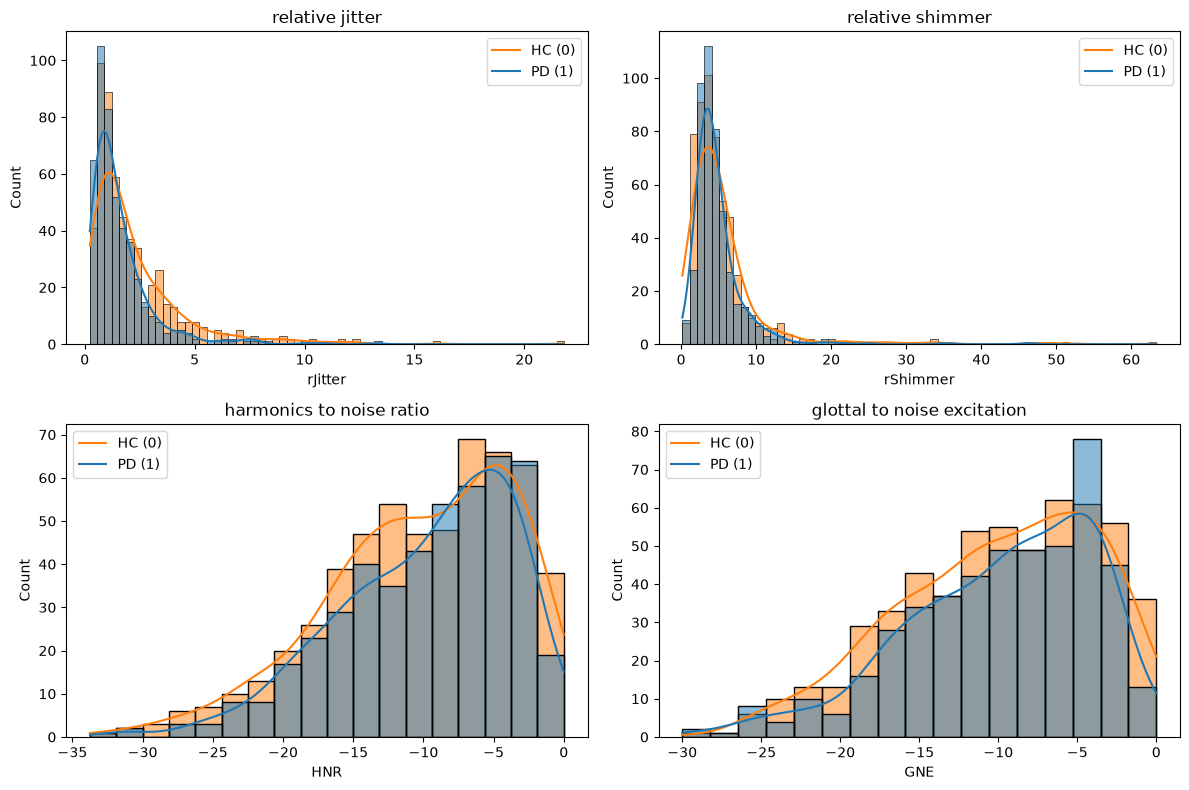

In [3]:
features_to_plot = {
    "rJitter": "relative jitter",
    "rShimmer": "relative shimmer",
    "HNR": "harmonics to noise ratio",
    "GNE": "glottal to noise excitation",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (feature, description) in enumerate(features_to_plot.items()):
    sns.histplot(data=df, x=feature, hue="label", ax=axes[i], kde=True)
    axes[i].set_title(description)
    axes[i].legend(["HC (0)", "PD (1)"])

plt.tight_layout()
plt.show()

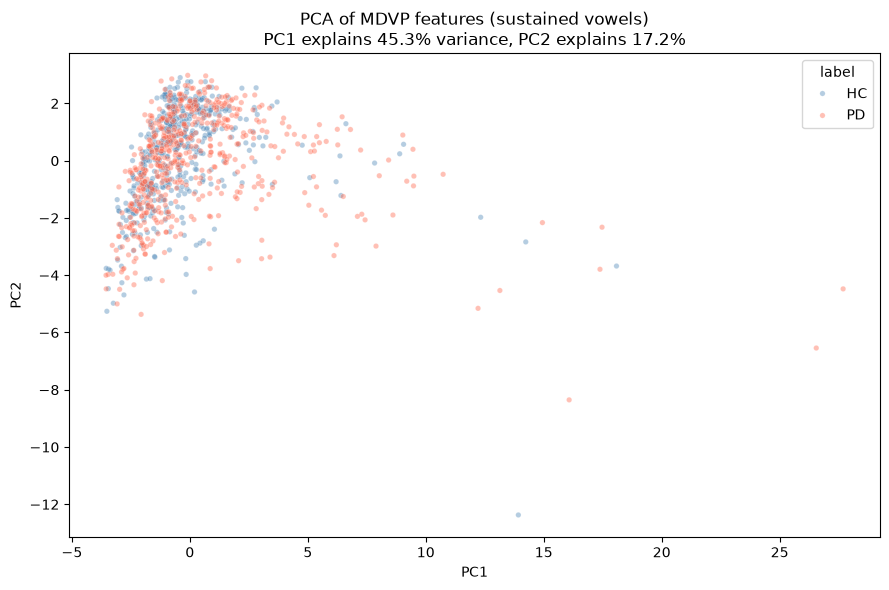

In [4]:
feature_cols = [c for c in df.columns if c not in ("AudioPath", "label")]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": df["label"].map({0: "HC", 1: "PD"}),
})

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=pca_df, x="PC1", y="PC2",
    hue="label", alpha=0.4, s=15,
    palette={"HC": "steelblue", "PD": "tomato"},
    ax=ax,
)
ax.set_title(
    f"PCA of MDVP features (sustained vowels)\n"
    f"PC1 explains {pca.explained_variance_ratio_[0]*100:.1f}% variance, "
    f"PC2 explains {pca.explained_variance_ratio_[1]*100:.1f}%"
)
plt.tight_layout()
plt.show()

In [5]:
X = df[feature_cols].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(classification_report(y_test, rf.predict(X_test), target_names=["HC", "PD"]))

              precision    recall  f1-score   support

          HC       0.66      0.69      0.68        95
          PD       0.73      0.70      0.71       112

    accuracy                           0.70       207
   macro avg       0.69      0.70      0.69       207
weighted avg       0.70      0.70      0.70       207



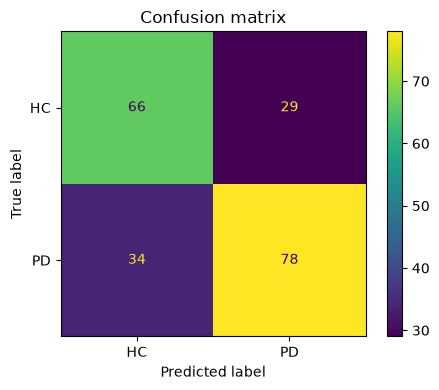

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf.predict(X_test),
    display_labels=["HC", "PD"],
    ax=ax,
)
ax.set_title("Confusion matrix")
plt.tight_layout()
plt.show()

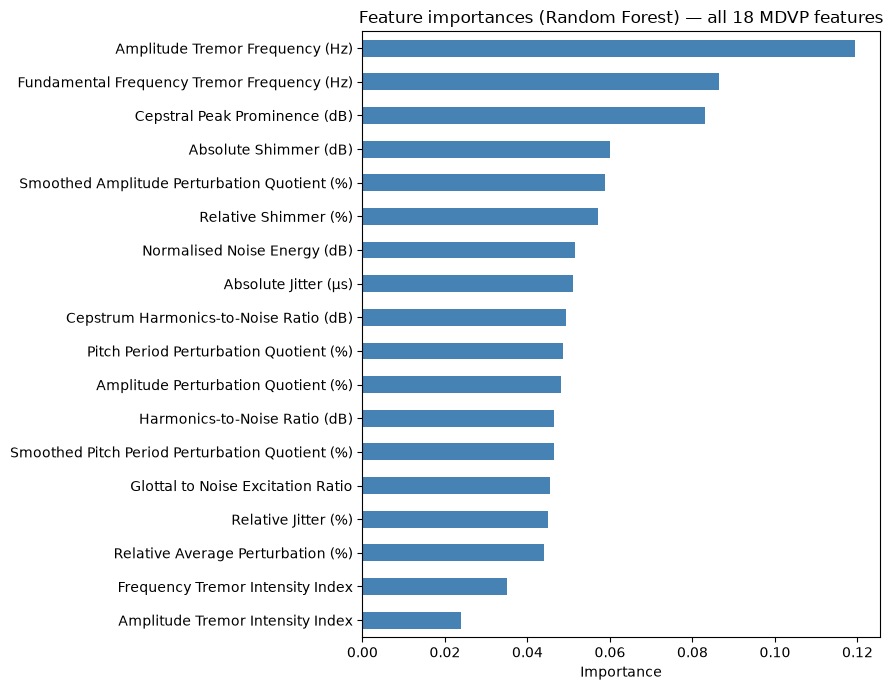

In [7]:
# human-readable names, per Table 5 (NeuroVoz paper)
readable = {
    "Jitter": "Absolute Jitter (μs)",
    "rJitter": "Relative Jitter (%)",
    "RAP": "Relative Average Perturbation (%)",
    "rPPQ": "Pitch Period Perturbation Quotient (%)",
    "rSPPQ": "Smoothed Pitch Period Perturbation Quotient (%)",
    "ShimmerDb": "Absolute Shimmer (dB)",
    "rShimmer": "Relative Shimmer (%)",
    "APQ": "Amplitude Perturbation Quotient (%)",
    "sAPQ": "Smoothed Amplitude Perturbation Quotient (%)",
    "CPP": "Cepstral Peak Prominence (dB)",
    "HNR": "Harmonics-to-Noise Ratio (dB)",
    "CHNR": "Cepstrum Harmonics-to-Noise Ratio (dB)",
    "GNE": "Glottal to Noise Excitation Ratio",
    "NNE": "Normalised Noise Energy (dB)",
    "FTRI": "Frequency Tremor Intensity Index",
    "ATRI": "Amplitude Tremor Intensity Index",
    "FFTR": "Fundamental Frequency Tremor Frequency (Hz)",
    "ATRF": "Amplitude Tremor Frequency (Hz)",
}

importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_readable = importances.sort_values().copy()
top_readable.index = [readable.get(f, f) for f in top_readable.index]

fig, ax = plt.subplots(figsize=(9, 7))
top_readable.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature importances (Random Forest) — all 18 MDVP features")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()